The primary goal of the Product Portfolio Analysis is to strategically assess our product lineup to make data-driven decisions on investment, marketing, and product development. 

By categorising products into Stars, Cash Cows, Question Marks, or Dogs, This aim to:

- Maximise Profitability
- Optimise Resource Allocation
- Innovate and Evolve

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

# Assuming you've set your project and dataset
project_id = 'jr-data-training'
dataset_id = 'dbt_cafeanalytics'

# Function to query BigQuery and return a DataFrame
def query_bigquery(sql):
    return pd.read_gbq(sql, project_id=project_id, progress_bar_type=None)

# List of tables you want to query, replace this with dynamic fetching if needed
tables = ['paymentStatusDim', 'productDim', 'timeDim', 'openingHoursDim', 'customerDim', 'fact_orders', 'fact_product_sales']  
dfs = {}

# Loop through tables and query each, storing each in the dfs dictionary
for table in tables:
    sql = f"SELECT * FROM `{project_id}.{dataset_id}.{table}`"
    dfs[table] = query_bigquery(sql)
    # print(f"Data from {table}:", dfs[table].head(), "\n")  # Just printing the first few rows for each table as an example


/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_25232/1285153295.py:12: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  return pd.read_gbq(sql, project_id=project_id, progress_bar_type=None)
/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_25232/1285153295.py:12: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  return pd.read_gbq(sql, project_id=project_id, progress_bar_type=None)
/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_25232/1285153295.py:12: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  return pd.read_gbq(sql, pro

In [2]:
# Accessing individual DataFrames
# For example, to work with the paymentStatusDim DataFrame:
payment_status_df = dfs['paymentStatusDim']
timeDim_df = dfs['timeDim']
productDim_df = dfs['productDim']
openingHoursDim_df = dfs['openingHoursDim']
customerDim_df = dfs['customerDim']
fact_orders_df = dfs['fact_orders']
fact_product_sales_df = dfs['fact_product_sales']



- customerDim and fact_orders: Can be merged on customer_id to enrich orders with customer information.
- productDim and fact_product_sales: Merge on item_name to get detailed product information for each sale.
- timeDim: Merge with fact_orders and fact_product_sales on the date fields (date_created in sales tables and date_key in timeDim after formatting if necessary).
- openingHoursDim: This doesn't directly merge with sales data unless you're analyzing daily aggregates or opening hours' impact on sales.
- paymentStatusDim and fact_orders: Merge on status to enrich orders with readable status descriptions.


In [3]:
# Merge customerDim with fact_orders: Ensure that 'customer_id' is of the same type in both DataFrames
fact_orders_df['customer_id'] = fact_orders_df['customer_id'].astype(str)
customerDim_df['customer_id'] = customerDim_df['customer_id'].astype(str)
# Merge
orders_with_customer_info = pd.merge(fact_orders_df, customerDim_df, on='customer_id', how='left')



# Merge productDim with fact_product_sales: Merge on 'item_name'
sales_with_product_info = pd.merge(fact_product_sales_df, productDim_df, on='item_name', how='left')



# Example conversion, adjust formats as needed
fact_product_sales_df['date_key'] = pd.to_datetime(fact_product_sales_df['date_created']).dt.date
timeDim_df['date_key'] = pd.to_datetime(timeDim_df['date_key']).dt.date
# Merge
sales_with_time_info = pd.merge(fact_product_sales_df, timeDim_df, on='date_key', how='left')




# Merge paymentStatusDim with fact_orders: Ensure 'status' is of the same type
fact_orders_df['status'] = fact_orders_df['status'].astype(str)
payment_status_df['status'] = payment_status_df['status'].astype(str)
# Merge
orders_with_payment_status = pd.merge(fact_orders_df, payment_status_df, on='status', how='left')

perform analyses like 
- customer segmentation, 
- product performance review, 
- sales trends over time
- top-selling products, or trends that inform operational decisions.
- impact of operational hours on sales. 
- identifying your most valuable customers,


In [4]:
# Now you have a DataFrame that includes daily sales and corresponding operating hours information.
# You can filter this DataFrame to analyze days with special notes, comparing sales on these days vs. regular operating days.

# Aggregate fact_product_sales_df to daily sales
daily_sales = fact_product_sales_df.groupby(fact_product_sales_df['date_created'].dt.date).agg(total_daily_sales=('total_sales', 'sum')).reset_index()
# Convert 'date_created' in daily_sales to datetime, if not already done
daily_sales['date_created'] = pd.to_datetime(daily_sales['date_created'])
# Ensure 'actual_date' in openingHoursDim_df is also datetime
openingHoursDim_df['actual_date'] = pd.to_datetime(openingHoursDim_df['actual_date'])
# Now attempt the merge again
daily_sales_with_hours = pd.merge(daily_sales, openingHoursDim_df, left_on='date_created', right_on='actual_date', how='left')



How openingHoursDim Could Be Used:


Analyzing Sales Performance Relative to Operating Hours: By understanding when your café is open, including any special notes about closures or reduced hours, you can analyze sales data to see how performance varies on days with standard vs. non-standard hours. This requires aggregating sales data to a daily level to match the granularity of openingHoursDim.

Impact of Special Hours on Sales: Special hours or closures (like holidays) might have a significant impact on sales. By identifying these days using openingHoursDim and comparing sales on these days to your average, you can gauge the impact.

Operational Planning: Insights from combining sales data with operating hours can inform staffing and inventory decisions. For example, if sales significantly increase on days before a special closure, you might plan accordingly.

In [5]:
""" from ydata_profiling import ProfileReport
# distribution of order values across different customer segments, identify frequent customers, and analyze the range of order values and volumes.
# For orders_with_customer_info DataFrame
profile_orders_customers = ProfileReport(orders_with_customer_info, title="Orders with Customer Info Profile")
profile_orders_customers.to_file("orders_customers_profile.html") 
# or use .to_widget() to save the report as an HTML file

profile_orders_products = ProfileReport(sales_with_product_info, title="Orders with Product Info Profile")
profile_orders_products.to_file("orders_products_profile.html") 

profile_orders_payments = ProfileReport(orders_with_payment_status, title="Orders with Payment Info Profile")
profile_orders_payments.to_file("orders_payments_profile.html") 

profile_daily_sales_with_hours = ProfileReport(daily_sales_with_hours, title="daily_sales_with_hours Info Profile")
profile_daily_sales_with_hours.to_file("profile_daily_sales_with_hours_profile.html") 

# Assuming df is your DataFrame
sales_with_time_info['date_created'] = pd.to_datetime(sales_with_time_info['date_created'])
sales_with_time_info['date_key'] = pd.to_datetime(sales_with_time_info['date_key'])

profile_orders_sales = ProfileReport(sales_with_time_info, title="Orders with Sales Info Profile")
profile_orders_sales.to_file("orders_sales_profile.html") 

"""

' from ydata_profiling import ProfileReport\n# distribution of order values across different customer segments, identify frequent customers, and analyze the range of order values and volumes.\n# For orders_with_customer_info DataFrame\nprofile_orders_customers = ProfileReport(orders_with_customer_info, title="Orders with Customer Info Profile")\nprofile_orders_customers.to_file("orders_customers_profile.html") \n# or use .to_widget() to save the report as an HTML file\n\nprofile_orders_products = ProfileReport(sales_with_product_info, title="Orders with Product Info Profile")\nprofile_orders_products.to_file("orders_products_profile.html") \n\nprofile_orders_payments = ProfileReport(orders_with_payment_status, title="Orders with Payment Info Profile")\nprofile_orders_payments.to_file("orders_payments_profile.html") \n\nprofile_daily_sales_with_hours = ProfileReport(daily_sales_with_hours, title="daily_sales_with_hours Info Profile")\nprofile_daily_sales_with_hours.to_file("profile_dail

Trend Analysis: For each product, analyze the sales trend over time. Products in the:

- Introduction stage will show gradually increasing sales.
- Growth stage will have rapidly increasing sales.
- Maturity stage will show stable or plateauing sales.
- Decline stage will have decreasing sales.

In [6]:
# Assuming sales_with_product_info is already loaded and date_created is converted to datetime
sales_with_product_info['month_year'] = sales_with_product_info['date_created'].dt.to_period('M')

# Aggregate sales data
aggregated_sales = sales_with_product_info.groupby(['item_name', 'month_year']).agg(
    total_sales=('total_sales', 'sum'),
    units_sold=('quantity_sold', 'sum')
).reset_index()


/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_25232/2807957268.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sales_with_product_info['month_year'] = sales_with_product_info['date_created'].dt.to_period('M')


In [7]:
import plotly.express as px

# Let's assume 'aggregated_sales' is already in your environment and has the columns 'item_name', 'month_year', and 'units_sold'

# Pivot the data to have months as columns and items as rows with units sold as values
pivot_sales = aggregated_sales.pivot(index='month_year', columns='item_name', values='units_sold').fillna(0)

# Plotly requires dates in a specific format, so ensure 'month_year' is in datetime format
pivot_sales.index = pd.PeriodIndex(pivot_sales.index, freq='M').to_timestamp()

# Create the line chart with Plotly Express
fig = px.line(pivot_sales, x=pivot_sales.index, y=pivot_sales.columns,
              labels={'value': 'Units Sold', 'variable': 'Items', 'index': 'Month-Year'},
              title='Sales Trends by Product')

# Improve layout
fig.update_layout(
    xaxis=dict(
        title='Month-Year',
        tickmode='array',
        tickvals=pivot_sales.index,
        ticktext=[str(date) for date in pivot_sales.index],
        tickangle=-45
    ),
    yaxis=dict(
        title='Units Sold'
    )
)

# Show the plot
fig.show()


In [8]:
# Make sure 'date_created' is in the correct datetime format
sales_with_product_info['date_created'] = pd.to_datetime(sales_with_product_info['date_created'])

# Aggregate total sales and quantity sold per product per month_year
product_sales_summary = sales_with_product_info.groupby(['item_name', 'month_year']).agg(
    total_sales=('total_sales', 'sum'),
    quantity_sold=('quantity_sold', 'sum')
).reset_index()

# Calculate total sales for all products per month_year to get the market size over time
market_size = product_sales_summary.groupby('month_year')['total_sales'].sum()

# Calculate each product's monthly sales as a percentage of the market size to get relative market share
product_sales_summary = product_sales_summary.merge(market_size.rename('total_sales_market'), on='month_year')
product_sales_summary['relative_market_share'] = product_sales_summary['total_sales'] / product_sales_summary['total_sales_market']

# Calculate sales growth rate for each product as the month-over-month percentage change in quantity sold
product_sales_summary['sales_growth_rate'] = product_sales_summary.groupby('item_name')['quantity_sold'].pct_change().fillna(0)

# Get the average sales growth rate and relative market share for each product
product_bcg_data = product_sales_summary.groupby('item_name').agg(
    average_growth_rate=('sales_growth_rate', 'mean'),
    average_market_share=('relative_market_share', 'mean')
).reset_index()

# Categorize products based on the median of growth rate and market share
median_growth_rate = product_bcg_data['average_growth_rate'].median()
median_market_share = product_bcg_data['average_market_share'].median()

def categorize_product(row, median_growth, median_share):
    if row['average_growth_rate'] > median_growth and row['average_market_share'] > median_share:
        return 'Star'
    elif row['average_growth_rate'] > median_growth and row['average_market_share'] <= median_share:
        return 'Question Mark'
    elif row['average_growth_rate'] <= median_growth and row['average_market_share'] > median_share:
        return 'Cash Cow'
    elif row['average_growth_rate'] <= median_growth and row['average_market_share'] <= median_share:
        return 'Dog'
    else:
        return 'Uncategorized'

product_bcg_data['category'] = product_bcg_data.apply(
    lambda row: categorize_product(row, median_growth_rate, median_market_share), axis=1)

# Now sort within each category and get the top products
top_bcg_categories = {}
categories = ['Star', 'Question Mark', 'Cash Cow', 'Dog']

for category in categories:
    top_products = product_bcg_data[product_bcg_data['category'] == category]\
                    .sort_values(['average_growth_rate', 'average_market_share'], ascending=[False, False])\
                    .head(5)  # Get top 5 products
    top_bcg_categories[category] = top_products['item_name'].tolist()

# Print the top products in each BCG category
for category, top_products in top_bcg_categories.items():
    print(f"Top products in {category} category: {top_products}")



Top products in Star category: ['Omelette', 'Burger', "Koko Fried Chicken 'KFC' Bao", 'Quiche', 'Dirty Chai Latte']
Top products in Question Mark category: ['Plain Toast', 'White Hot Chocolate', 'Scone', 'Iced Chocolate with Cream', 'Homemade Sausage Roll']
Top products in Cash Cow category: ['Banana Bread', 'Espresso', 'Deep Fryer', 'Croissant', 'Fried Chicken on Ciabatta']
Top products in Dog category: ['Kids Crepes', 'Coffee Frappe', 'Chicken Risotto', 'Smashed Avo on Toast (V, VGO)', 'Carrot Cake']


In [9]:
product_bcg_data.sort_values(by=['average_growth_rate'])

,item_name,average_growth_rate,average_market_share,category
95,Zucchini Corn Fritters with Bacon (GFO),-0.25,0.002531,Dog
15,Chicken & Mushroom Crepe,-0.25,0.011820,Cash Cow
75,"Orange Almond Cake (GF,VG)",-0.25,0.001006,Dog
4,Affogato,-0.208333,0.007035,Cash Cow
50,Homemade Mixed Veg Frittata,-0.166667,0.001508,Dog
...,...,...,...,...
11,Burger,0.547343,0.008391,Star
83,Scone,0.561058,0.002011,Question Mark
94,White Hot Chocolate,0.653655,0.004530,Question Mark
73,Omelette,0.660289,0.006015,Star


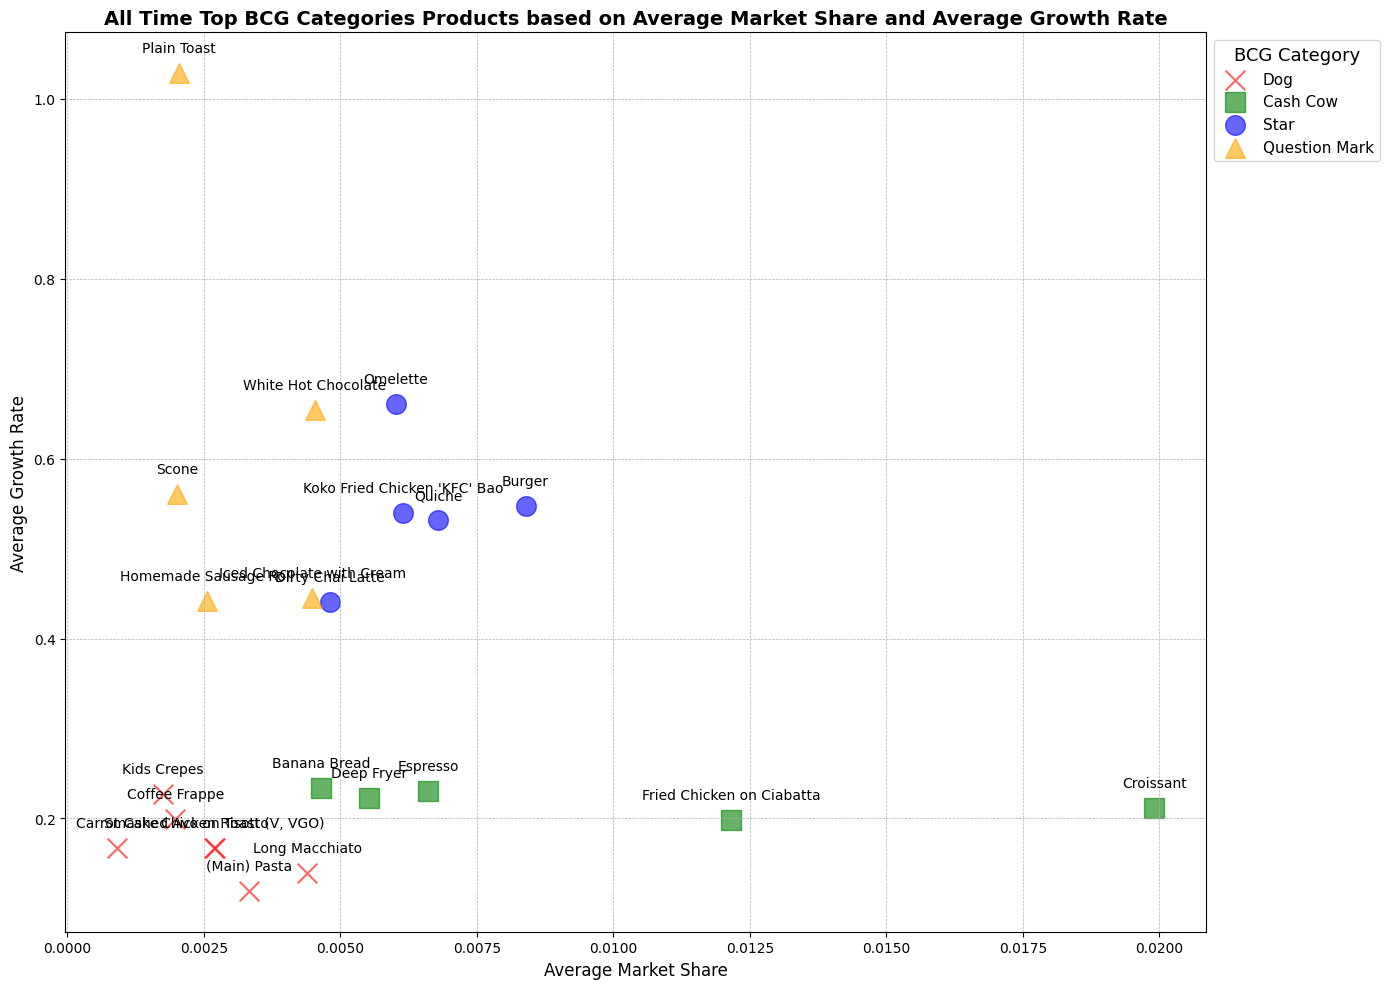

In [10]:
# Get the top 5 products in each category
product_bcg_data['rank_in_category'] = product_bcg_data.groupby('category')['average_growth_rate'].rank("dense", ascending=False)
top_products = product_bcg_data[product_bcg_data['rank_in_category'] <= 5]

# Initialize the figure
plt.figure(figsize=(14, 10))

# Define markers and colors for differentiation
markers = {'Star': 'o', 'Question Mark': '^', 'Cash Cow': 's', 'Dog': 'x', 'New Product': 'p'}
colors = {'Star': 'blue', 'Question Mark': 'orange', 'Cash Cow': 'green', 'Dog': 'red', 'New Product': 'purple'}

# Plot each category
for category in top_products['category'].unique():
    category_data = top_products[top_products['category'] == category]
    
    # Plot data points for this category
    plt.scatter(category_data['average_market_share'], category_data['average_growth_rate'], 
                s=200, alpha=0.6, marker=markers[category], color=colors[category],
                label=category)

# Adjust text annotations
for i, row in top_products.iterrows():
    plt.text(row['average_market_share'], row['average_growth_rate'] + 0.02,  # Offset the text slightly above the marker
             s=row['item_name'], color='black', ha='center', va='bottom')

# Customizing the plot
plt.title("All Time Top BCG Categories Products based on Average Market Share and Average Growth Rate", fontsize=14, fontweight='bold')
plt.xlabel("Average Market Share", fontsize=12)
plt.ylabel("Average Growth Rate", fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="BCG Category", title_fontsize='13', fontsize='11', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()  # Adjust the layout to fit everything
plt.show()




X-axis: Average market share is relatively low for all products, as the x-axis scale is between 0 and about 0.22. No product dominates in terms of market share within your sales data.

Y-axis: The growth rates vary, with some products showing negative growth (below 0), and others showing positive growth (above 0).

Top-Right Quadrant: Normally, this is where 'Stars' would be located, but it appears there are no products in your dataset that combine both a high market share and a high growth rate.

Top-Left Quadrant: 'Question Marks' would fall here; they have high growth rates but low market shares. Some products are positioned here, indicating potential if they can increase their market share.

Bottom-Right Quadrant: This would be the 'Cash Cows' area, with high market share and low growth rate. However, based on the x-axis scale, no products are significant market share leaders.

Bottom-Left Quadrant: 'Dogs' are found here with low growth and low market share. Several products fall into this category, which might either require reevaluation or discontinuation.

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_25232/2041032072.py:3: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_25232/2041032072.py:59: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_25232/2041032072.py:61: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/ms/5jxhpktn4ts

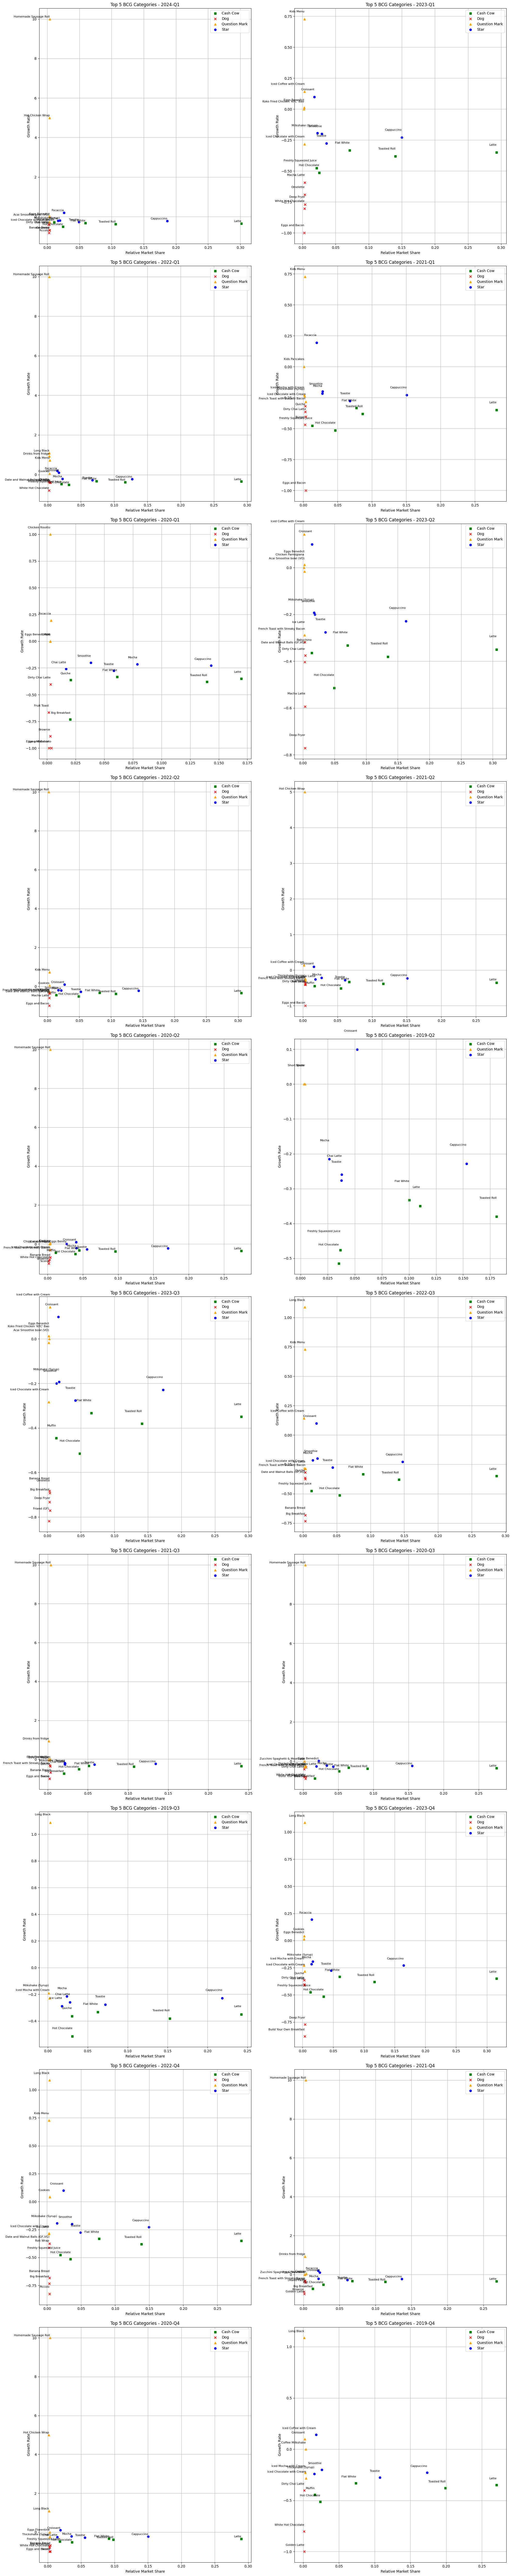

In [11]:
# Prepare the data
sales_with_product_info['date_created'] = pd.to_datetime(sales_with_product_info['date_created'])
sales_with_product_info['quarter'] = sales_with_product_info['date_created'].dt.to_period('Q').dt.strftime('%Y-Q%q')

# Aggregate sales data per product per quarter
quarterly_sales_summary = sales_with_product_info.groupby(['item_name', 'quarter'], as_index=False).agg(
    total_sales=('total_sales', 'sum')
)

# Calculate market size for each quarter and relative market share
market_size_quarterly = quarterly_sales_summary.groupby('quarter')['total_sales'].sum().reset_index(name='market_total_sales')
quarterly_sales_summary = pd.merge(quarterly_sales_summary, market_size_quarterly, on='quarter')
quarterly_sales_summary['relative_market_share'] = quarterly_sales_summary['total_sales'] / quarterly_sales_summary['market_total_sales']

# Pivot sales data for growth rate calculation
pivot_data = quarterly_sales_summary.pivot(index='item_name', columns='quarter', values='total_sales').fillna(0)

# Determine the latest two quarters for analysis
sorted_quarters = sorted(pivot_data.columns)
latest_quarter, previous_quarter = sorted_quarters[-1], sorted_quarters[-2]

# Calculate growth rate from previous quarter to the latest quarter for each product
pivot_data['growth_rate'] = (pivot_data[latest_quarter] - pivot_data[previous_quarter]) / pivot_data[previous_quarter].replace(0, np.nan)

# Merge growth rate back to quarterly_sales_summary
growth_rate_series = pivot_data['growth_rate'].reset_index()
quarterly_sales_summary = pd.merge(quarterly_sales_summary, growth_rate_series, on='item_name')

# Ensure 'growth_rate' is filled with 0 for NaN values
quarterly_sales_summary['growth_rate'] = quarterly_sales_summary['growth_rate'].fillna(0)

# Determine the latest quarter
latest_quarter = quarterly_sales_summary['quarter'].max()

# Make sure to calculate or recalculate the 'category' after updating 'growth_rate'
median_market_share = quarterly_sales_summary['relative_market_share'].median()
median_growth_rate = quarterly_sales_summary['growth_rate'].median()

def categorize_bcg(row):
    if row['relative_market_share'] >= median_market_share and row['growth_rate'] >= median_growth_rate:
        return 'Star'
    elif row['relative_market_share'] < median_market_share and row['growth_rate'] >= median_growth_rate:
        return 'Question Mark'
    elif row['relative_market_share'] >= median_market_share and row['growth_rate'] < median_growth_rate:
        return 'Cash Cow'
    else:
        return 'Dog'

# Apply categorization
quarterly_sales_summary['category'] = quarterly_sales_summary.apply(categorize_bcg, axis=1)

# Define quarters of interest
quarters_of_interest = ['2024-Q1', '2023-Q1', '2022-Q1', '2021-Q1', '2020-Q1', '2023-Q2', '2022-Q2', '2021-Q2', '2020-Q2', '2019-Q2', '2023-Q3', '2022-Q3', '2021-Q3', '2020-Q3', '2019-Q3', '2023-Q4', '2022-Q4', '2021-Q4', '2020-Q4', '2019-Q4']

# Function to categorize and retrieve top 5 products for a given quarter
def get_top_5_for_quarter(quarter):
    quarter_data = quarterly_sales_summary[quarterly_sales_summary['quarter'] == quarter]
    # Categorize if not already done, or make sure the categorization is relevant for this quarter
    quarter_data['category'] = quarter_data.apply(categorize_bcg, axis=1)
    # Get top 5 products for this quarter
    top_5 = quarter_data.groupby('category').apply(lambda x: x.nlargest(5, 'total_sales')).reset_index(drop=True)
    return top_5

# Define a function to plot top 5 BCG matrix products for a given quarter
def plot_top_bcg_products(ax, data, quarter_str, title):
    categories = data['category'].unique()
    markers = {'Star': 'o', 'Question Mark': '^', 'Cash Cow': 's', 'Dog': 'x', 'Uncategorized': 'p'}
    colors = {'Star': 'blue', 'Question Mark': 'orange', 'Cash Cow': 'green', 'Dog': 'red', 'Uncategorized': 'grey'}

    for category in categories:
        category_data = data[data['category'] == category]
        ax.scatter(category_data['relative_market_share'], category_data['growth_rate'], 
                   marker=markers[category], color=colors[category], label=category)
        
        # Annotate product names
        for i, row in category_data.iterrows():
            ax.text(row['relative_market_share'], row['growth_rate'] + 0.05, row['item_name'],
                    fontsize=8, ha='right', va='bottom')

    ax.set_title(title)
    ax.set_xlabel('Relative Market Share')
    ax.set_ylabel('Growth Rate')
    ax.grid(True)
    ax.legend()

# Adjust the number of rows based on the number of quarters to plot
n_rows = len(quarters_of_interest) // 2 + len(quarters_of_interest) % 2
fig, axs = plt.subplots(n_rows, 2, figsize=(20, 10 * n_rows))
axs = axs.flatten()

for i, quarter in enumerate(quarters_of_interest):
    top_5_for_quarter = get_top_5_for_quarter(quarter)
    plot_top_bcg_products(axs[i], top_5_for_quarter, quarter, f'Top 5 BCG Categories - {quarter}')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()


In [12]:
# Adjusting the function to get only the top 1 product for each category per quarter
def get_top_1_for_quarter(quarter):
    quarter_data = quarterly_sales_summary[quarterly_sales_summary['quarter'] == quarter].copy()
    quarter_data['category'] = quarter_data.apply(categorize_bcg, axis=1)
    top_1 = quarter_data.groupby('category').apply(lambda x: x.nlargest(1, 'total_sales')).reset_index(drop=True)
    return top_1

# Printing the top 1 products for each BCG category for each quarter from Q2 2019 until Q1 2024
top_1_products_all_quarters = {quarter: get_top_1_for_quarter(quarter) for quarter in quarters_of_interest}

# Since directly printing all at once might be too extensive, let's format the results for easier readability
formatted_results = []

for quarter, results in top_1_products_all_quarters.items():
    for _, row in results.iterrows():
        formatted_results.append({
            'Quarter': quarter,
            'Category': row['category'],
            'Product': row['item_name'],
            'Total Sales': row['total_sales'],
            'Market Share': f"{row['relative_market_share']*100:.2f}%",
            'Growth Rate': f"{row['growth_rate']*100:.2f}%"
        })

formatted_results_df = pd.DataFrame(formatted_results)
#formatted_results_df.to_csv('sales_data_summary.csv', index=False)


/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_25232/3828641821.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_25232/3828641821.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/ms/5jxhpktn4ts_bkyr5s47mbmh0000gn/T/ipykernel_25232/3828641821.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping col

In [13]:
def plot_sales_per_year(df, products_to_plot):
    """
    Plot monthly sales for given products in each year present in the DataFrame.

    Parameters:
    df (pd.DataFrame): DataFrame containing sales data with 'date_created' and 'total_sales'.
    products_to_plot (list): List of product names to plot.
    """
    # Ensure 'date_created' is a datetime dtype and extract year and month
    df['date_created'] = pd.to_datetime(df['date_created'])
    df['year'] = df['date_created'].dt.year
    df['month'] = df['date_created'].dt.month

    # Group by 'item_name', 'year', and 'month' and sum the 'total_sales'
    df_grouped = df.groupby(['item_name', 'year', 'month'])['total_sales'].sum().reset_index()

    # Get unique years to plot each year's data
    years = df_grouped['year'].unique()

    # Plotting separate line chart for each year
    for year in years:
        # Create figure for each year
        plt.figure(figsize=(15, 7))

        # Filter the DataFrame for the specific year
        df_year = df_grouped[df_grouped['year'] == year]

        # Loop through each product and plot its sales for the year
        for product in products_to_plot:
            if product in df_year['item_name'].values:
                # Prepare data for plotting
                df_product_year = df_year[df_year['item_name'] == product]
                plt.plot(df_product_year['month'], df_product_year['total_sales'], marker='o', label=product)

        plt.xlabel('Month')
        plt.ylabel('Total Sales')
        plt.title(f'Sales Performance of Selected Items in {year}')
        plt.legend(title='Items', loc='upper left', bbox_to_anchor=(1, 1))
        plt.grid(True)
        plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        plt.tight_layout()
        plt.show()


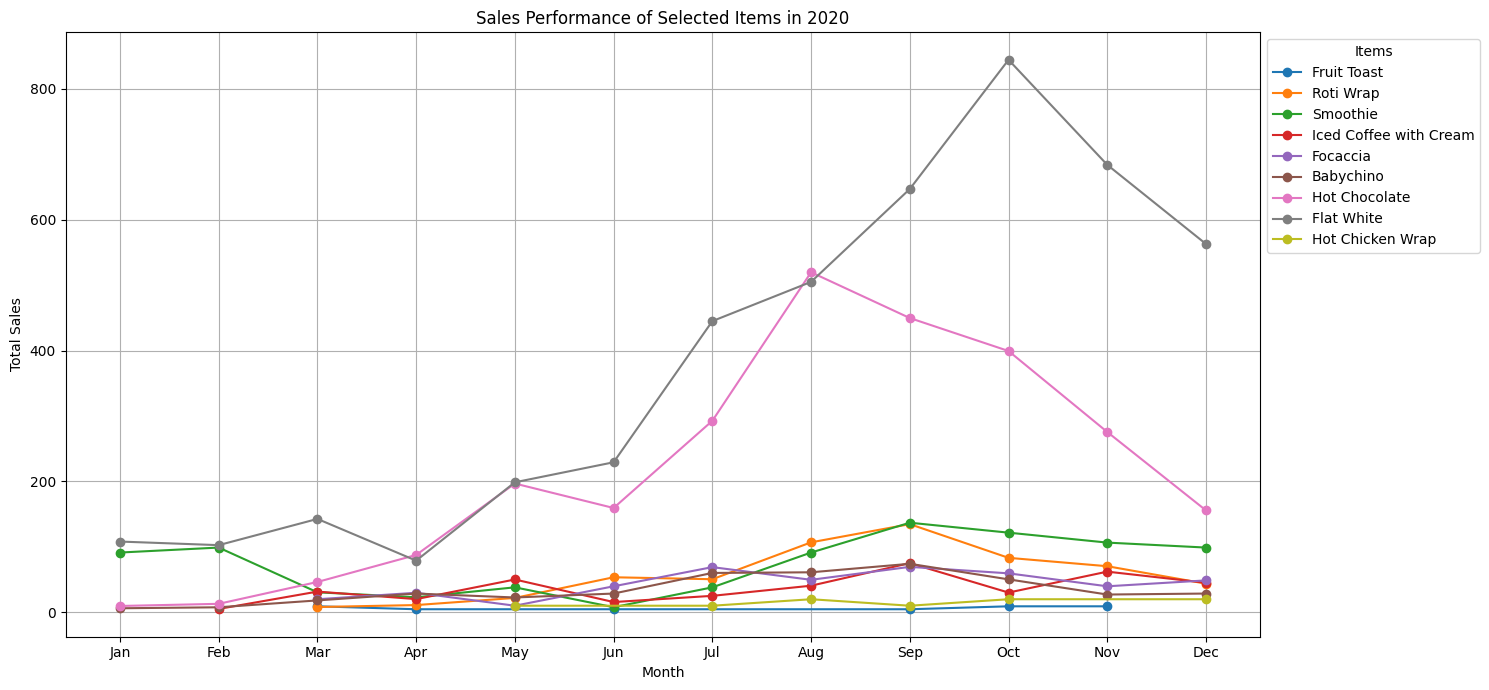

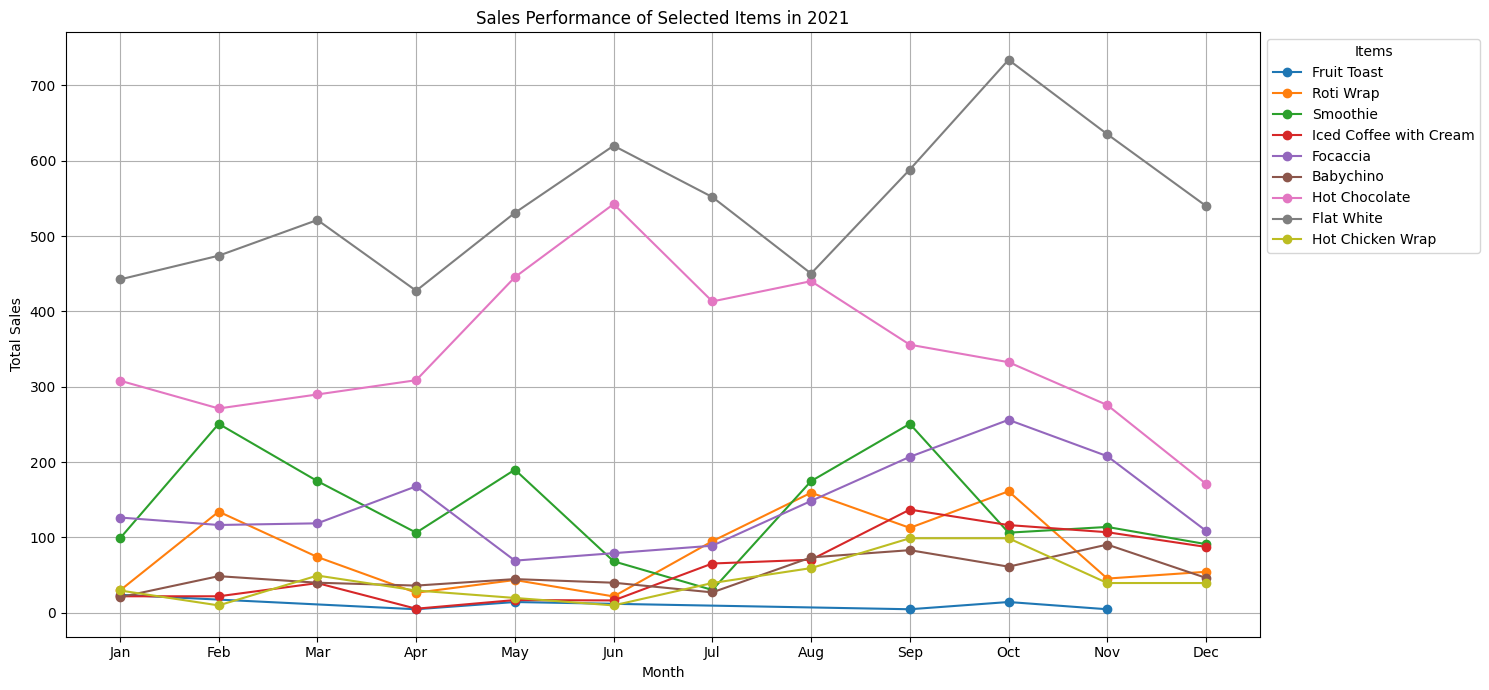

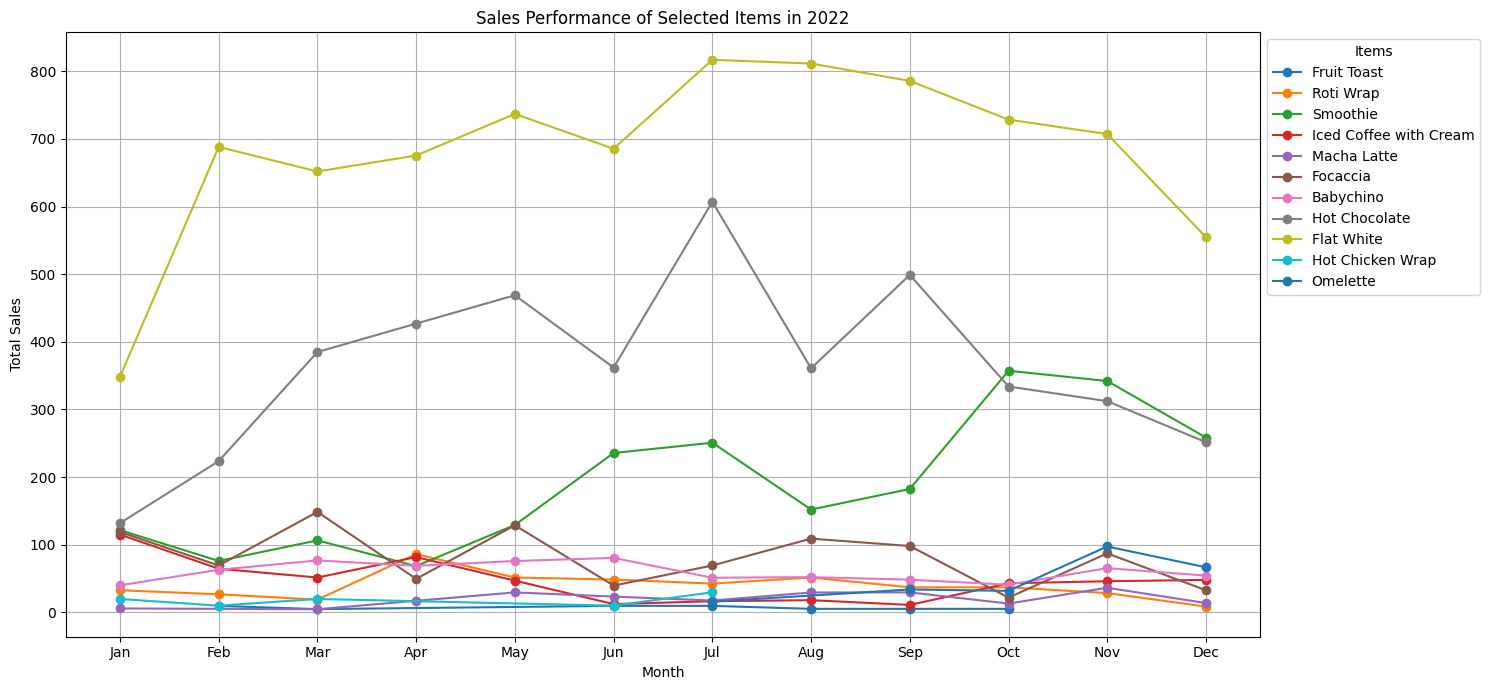

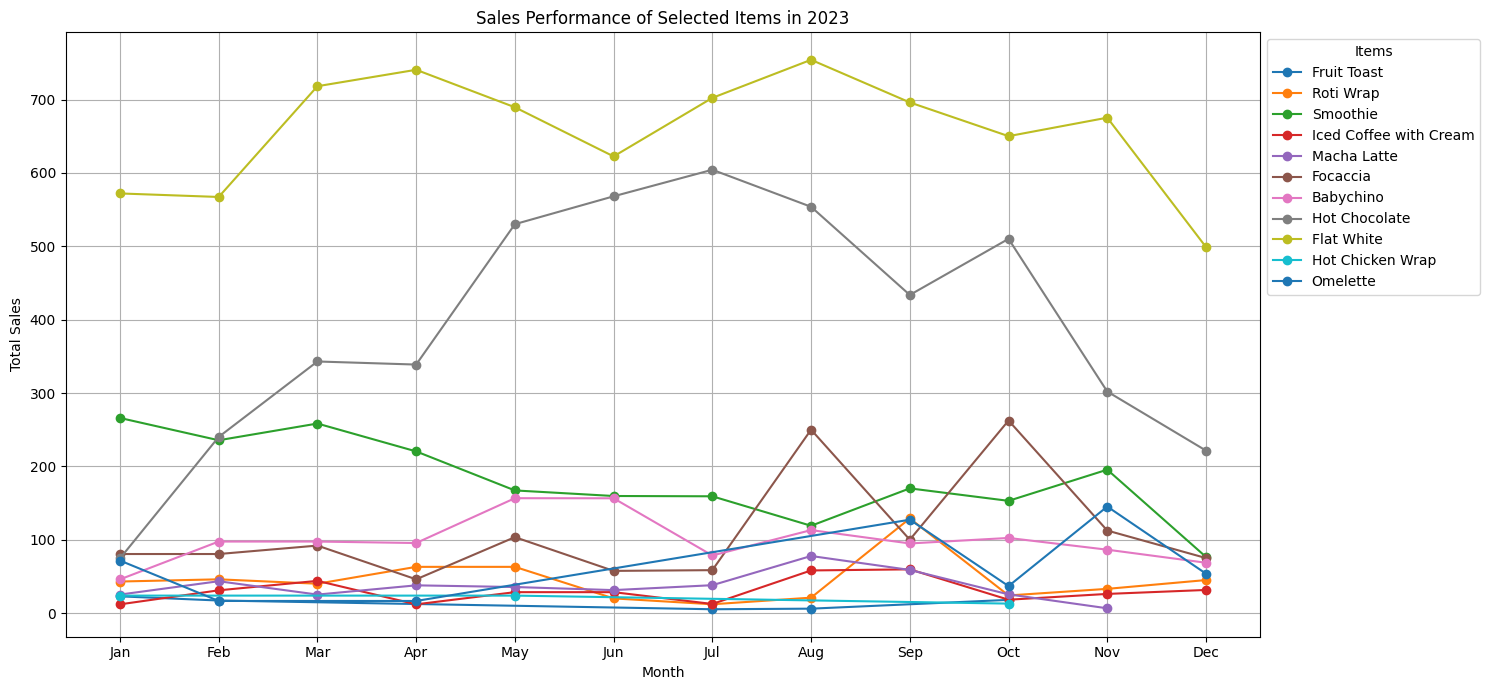

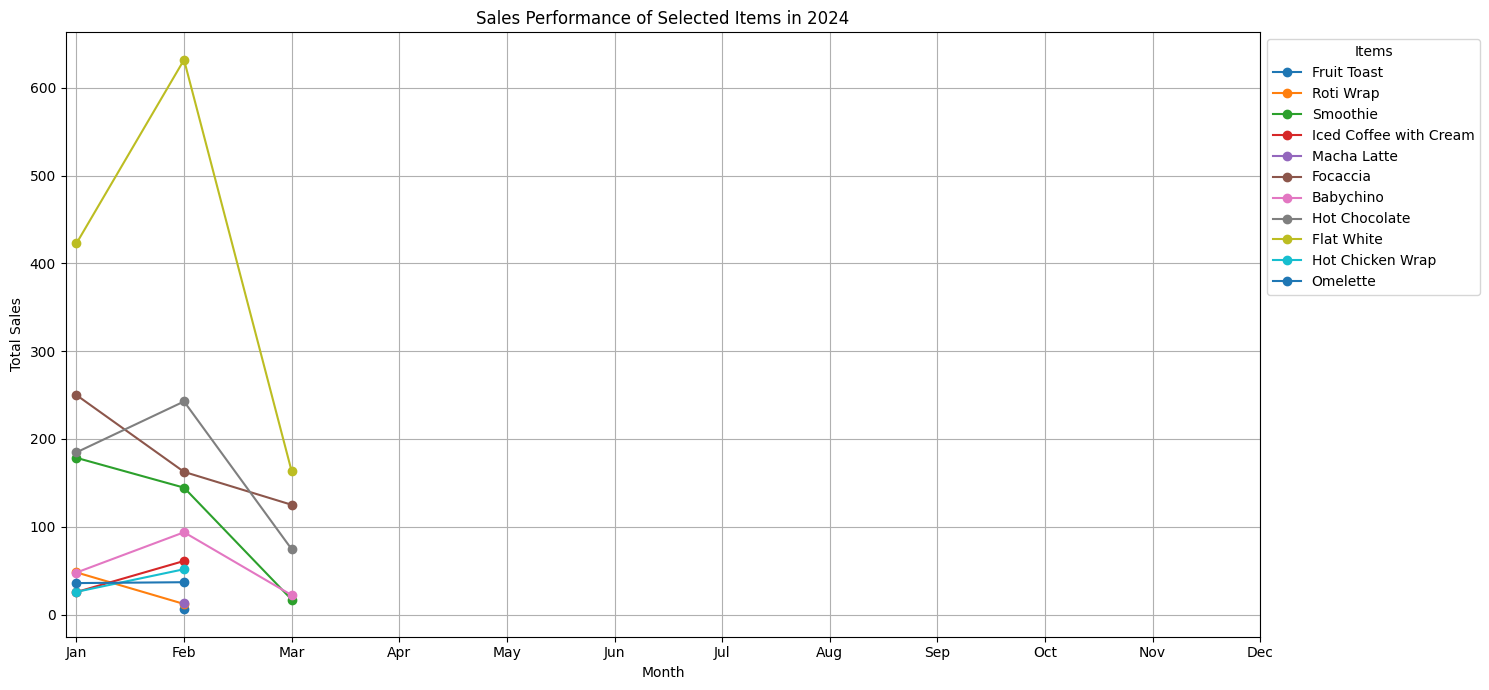

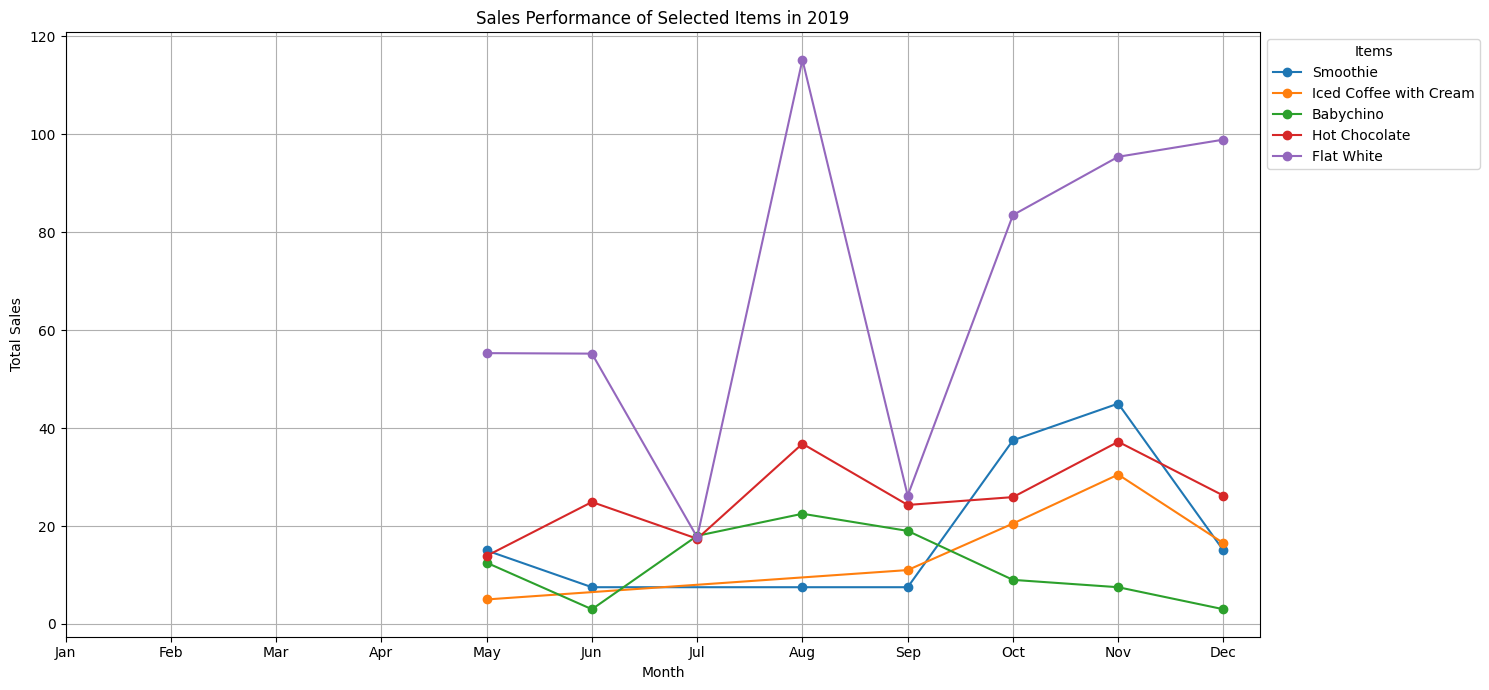

In [35]:
items_to_plot = [
'Fruit Toast',
'Roti Wrap',
'Iced Latte',
'Smoothie',
'Iced Coffee with Cream',
'Macha Latte',
'Focaccia',
'Babychino',
'Hot Chocolate',
'Flat White',
'Hot Chicken Wrap',
'Omelette'
]

# Call the function with the DataFrame and list of products
plot_sales_per_year(sales_with_product_info, items_to_plot)

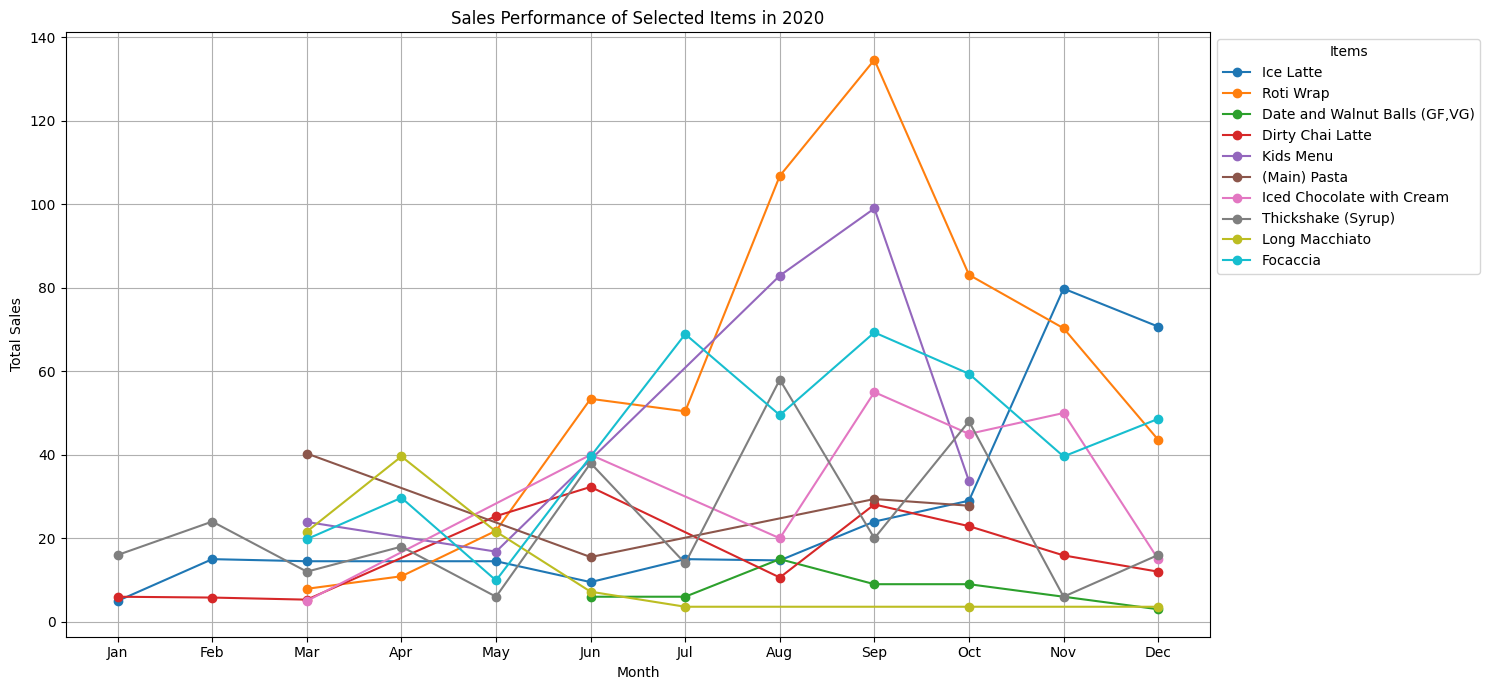

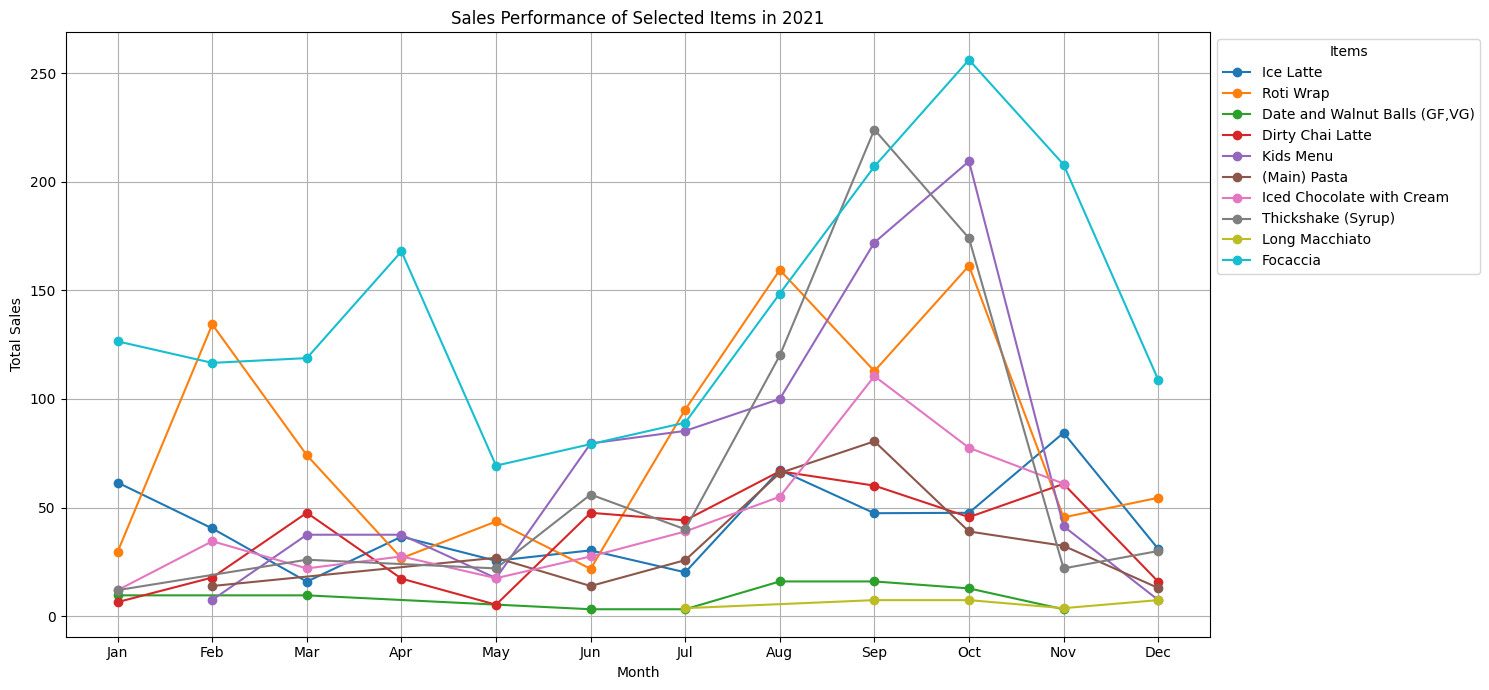

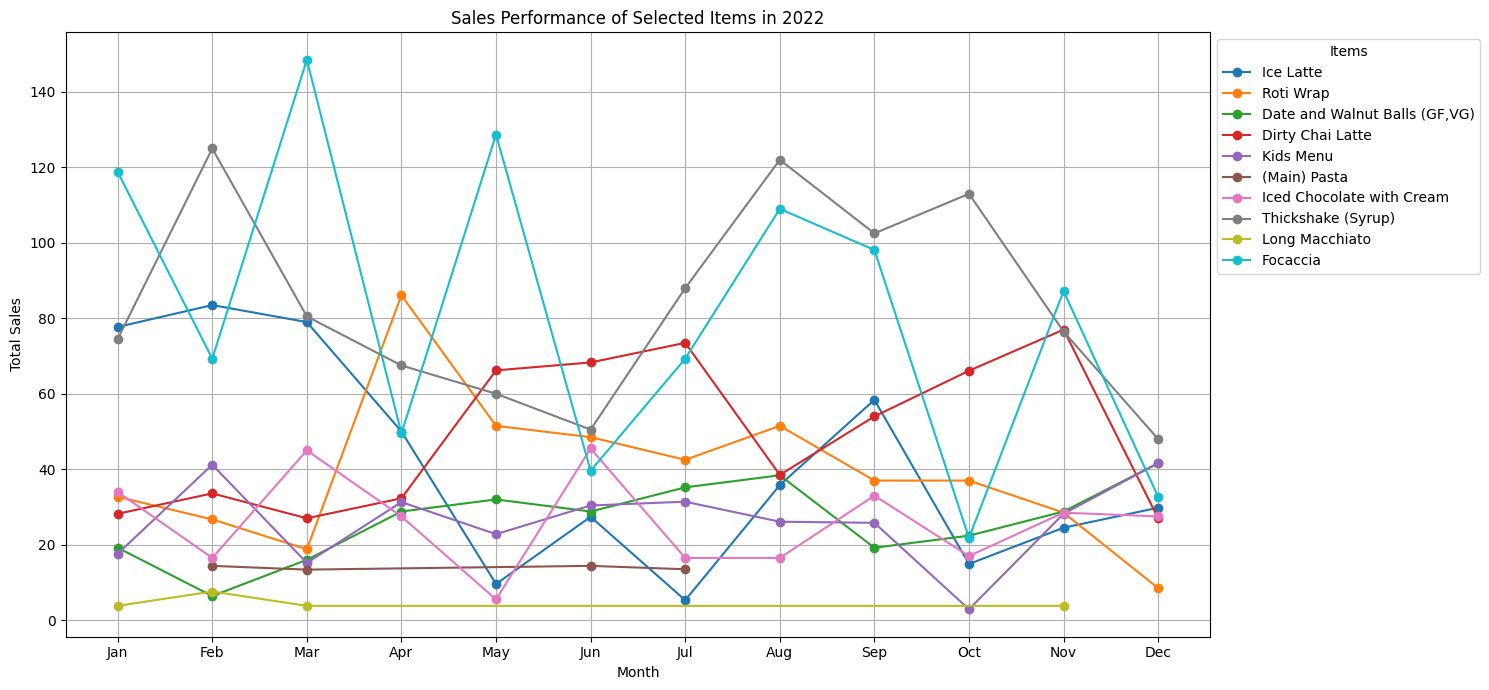

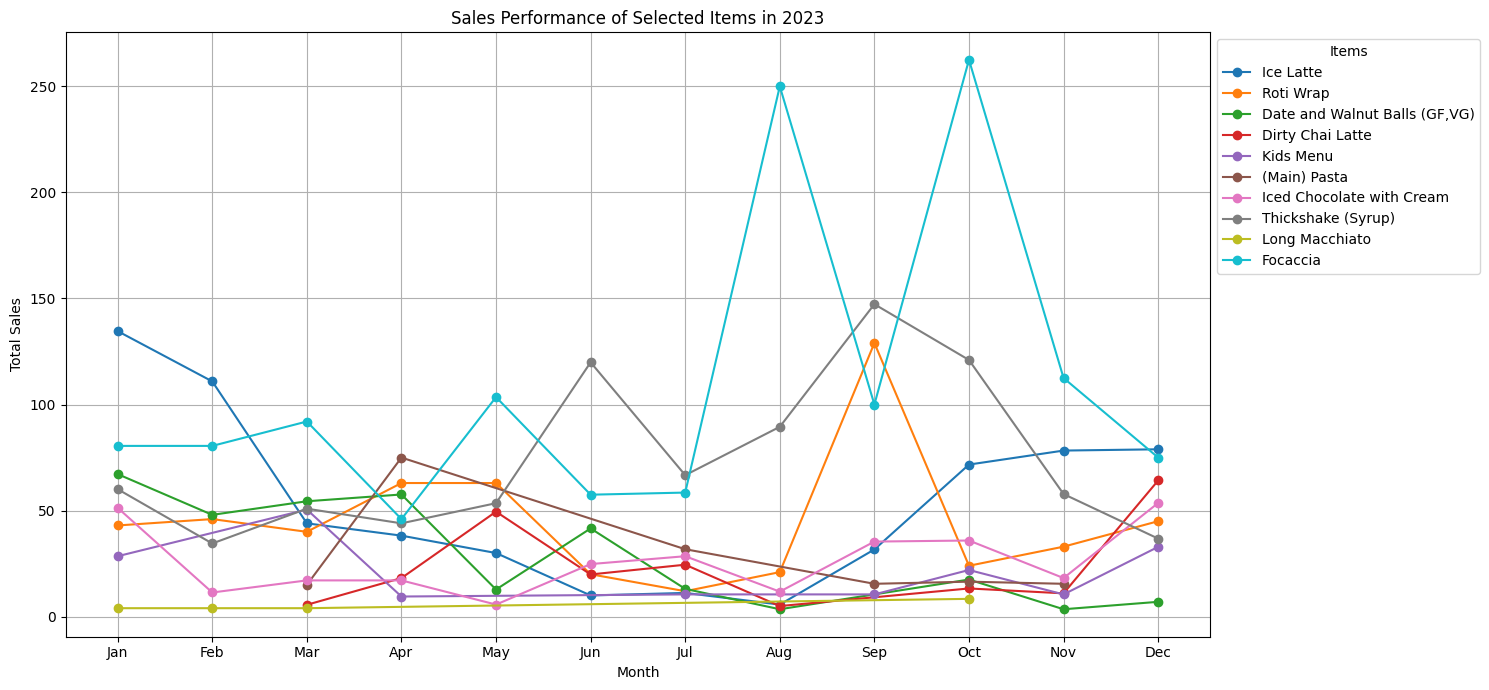

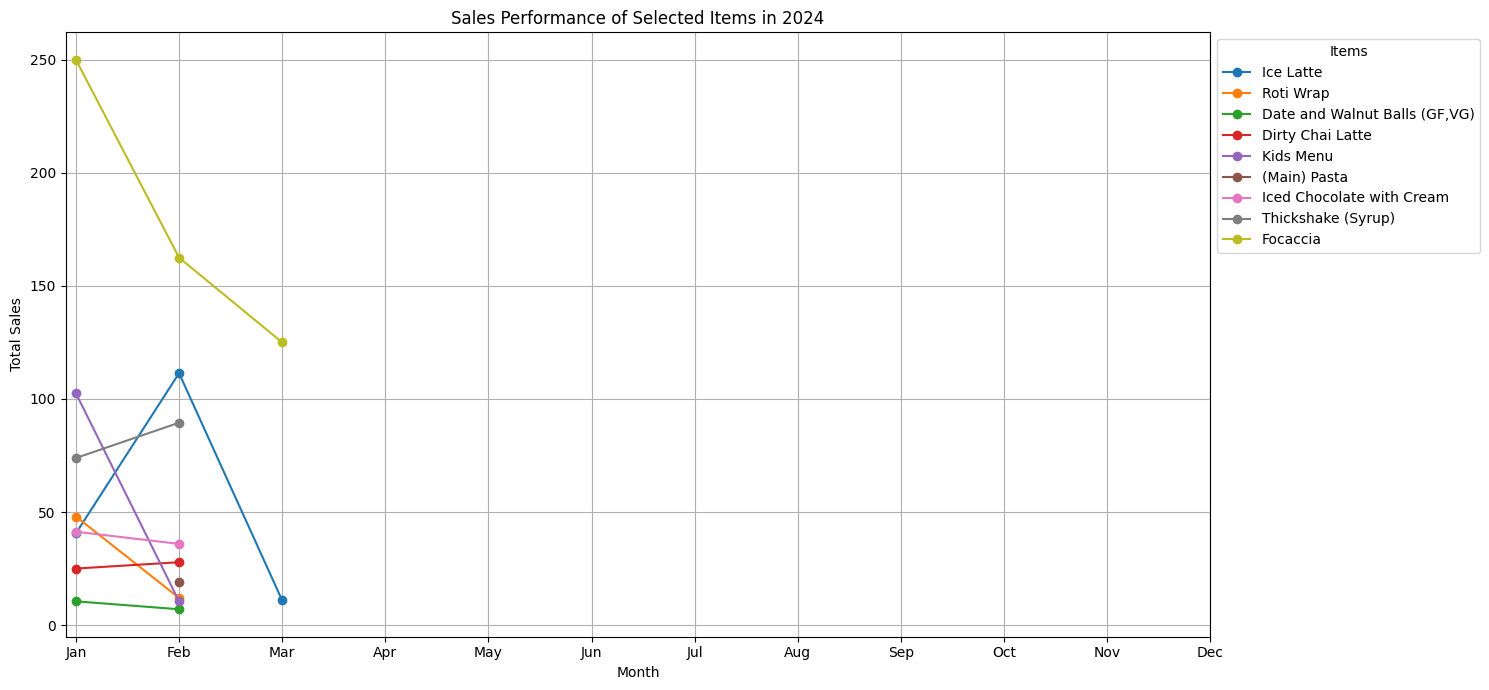

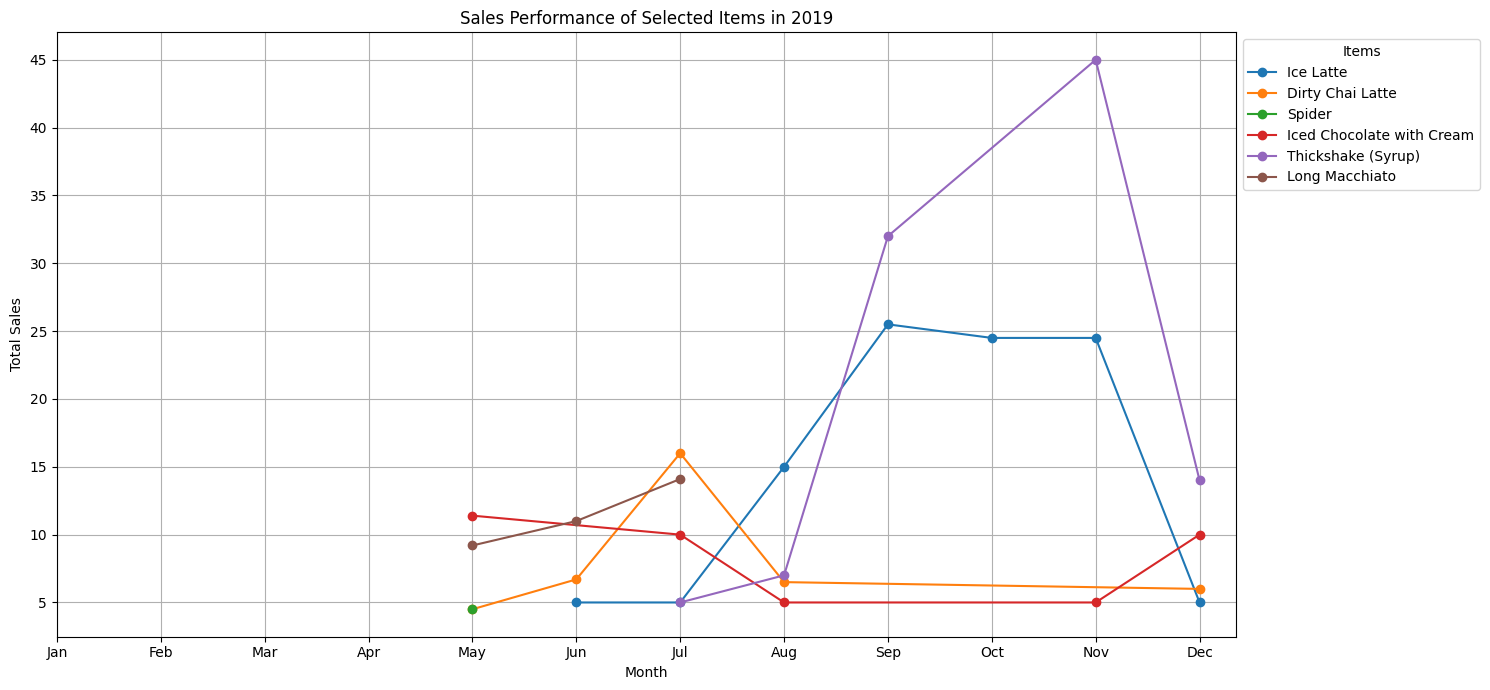

In [15]:



items_to_plot2 = [
"Ice Latte", "Roti Wrap", "Date and Walnut Balls (GF,VG)",
    "Dirty Chai Latte", "Kids Menu", "(Main) Pasta", "Spider", "Iced Chocolate with Cream",
    "Thickshake (Syrup)", "Long Macchiato", "Focaccia"
]

# Call the function with the DataFrame and list of products
plot_sales_per_year(sales_with_product_info, items_to_plot2)

## Probability of a Customer Returning After Purchasing a Specific Item
To find this probability for a specific item (e.g., a latte):

Filter the records to find first purchases where the item was a latte.
Among these filtered records, determine how many of these customers returned.
Calculate the probability 
�
(
return
∣
latte
)
P(return∣latte) as the ratio of returning customers who bought a latte on their first visit to the total number of first-time latte buyers.


1. Transactions on the same day as the purchase are not considered returns.
2. Only transactions within a 60-day window post-purchase are considered valid returns.
3. Taking all orders of every distinct customer into consideration. Not only first purchase.
4. If the Updated Probability of Return is greater than 0.5 and both the upper and lower bounds of the CI are higher than 0.5, it is considered low risk.
5. If the Updated Probability of Return is less than 0.5 and the upper bound of the CI is less than 0.5, it is considered high risk.
6. Otherwise, it is considered moderate risk.

In [29]:
# Convert 'date_created' to datetime and 'customer_id' to integer
sales_with_product_info['date_created'] = pd.to_datetime(sales_with_product_info['date_created'])
sales_with_product_info['customer_id'] = sales_with_product_info['customer_id'].astype(int)

# Sort sales data by 'customer_id' and 'date_created'
sorted_sales = sales_with_product_info.sort_values(by=['customer_id', 'date_created'])

# Create a column for the next purchase date by shifting 'date_created' within each customer group
sorted_sales['next_purchase_date'] = sorted_sales.groupby('customer_id')['date_created'].shift(-1)

# Calculate the days to the next purchase
sorted_sales['days_to_next_purchase'] = (sorted_sales['next_purchase_date'] - sorted_sales['date_created']).dt.days

# Filter valid returns: not on the same day and within 60 days
valid_returns = sorted_sales[(sorted_sales['days_to_next_purchase'] > 0) & (sorted_sales['days_to_next_purchase'] <= 60)]

# Count occurrences of each item in valid returns and total sales
item_return_counts = valid_returns['item_name'].value_counts()
total_item_sales = sales_with_product_info['item_name'].value_counts()

# Create a DataFrame to store the results
results_df = pd.DataFrame(total_item_sales).reset_index()
results_df.columns = ['Item', 'Total Sales']
results_df['Return Counts'] = results_df['Item'].map(item_return_counts).fillna(0)

# Compute base probabilities
results_df['Base Probability of Return'] = results_df['Return Counts'] / results_df['Total Sales']

# Apply Bayesian updating for updated probabilities
prior_counts = 1  # simple prior count
prior_success = prior_counts * 0.5  # naive prior probability of 50%
results_df['Updated Probability of Return'] = (results_df['Return Counts'] + prior_success) / (results_df['Total Sales'] + prior_counts)

In [30]:
# Define a function to calculate Wilson confidence intervals
def calculate_wilson_ci(row):
    if row['Total Sales'] > 0:
        ci_low, ci_high = proportion_confint(count=row['Return Counts'], nobs=row['Total Sales'], alpha=0.05, method='wilson')
        return pd.Series([ci_low, ci_high])
    return pd.Series([0, 0])

def determine_churn_risk(probability, ci_lower, ci_upper):
    if probability > 0.5:
        if ci_upper > 0.5 and ci_lower > 0.5:
            return 'Low'
        else:
            return 'Moderate'
    else:
        if ci_upper < 0.5:
            return 'High'
        else:
            return 'Moderate'


In [31]:
# Apply the function to each row in the DataFrame
results_df[['CI Lower', 'CI Upper']] = results_df.apply(calculate_wilson_ci, axis=1)

# Determine churn risk based on updated probability of return and confidence intervals
results_df['Churn Risk'] = results_df.apply(lambda row: determine_churn_risk(row['Updated Probability of Return'], row['CI Lower'], row['CI Upper']), axis=1)

# Export the DataFrame to a CSV file
results_df.to_csv('conditional_probability_results_with_wilson_ci.csv', index=False)